Comparison of a few models to decide the baseline model for finetuning

uses 2 models -

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# CODE BLOCK 1: UNIVERSAL SETUP & PREPROCESSING (Corrected)

import os
import shutil
import zipfile
import xml.etree.ElementTree as ET
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from google.colab import drive
from PIL import Image

# 1. Mount Drive & Define Paths
if not os.path.exists('/content/drive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

DRIVE_ZIP_PATH = '/content/drive/MyDrive/FloW_RI_Sequence_1_10.zip'
DATA_DIR = '/content/FloW_RI_Dataset'
YOLO_DIR = '/content/trash_dataset_yolo_comparison'

# 2. Unzip Data (Only if needed)
if not os.path.exists(DATA_DIR):
    print(f"Unzipping data from Drive...")
    if not os.path.exists(DRIVE_ZIP_PATH):
        raise FileNotFoundError(f"Zip file not found at {DRIVE_ZIP_PATH}")

    os.makedirs(DATA_DIR, exist_ok=True)
    with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print("Unzipping complete.")

# 3. ROBUST FIND ROOT FOLDER Logic
# We need to find the folder that *contains* the sequence folders (1, 2, 3...)
UNZIPPED_DIR = None

# Walk through the directory to find a '1' folder that has a 'Pic' subfolder
for root, dirs, files in os.walk(DATA_DIR):
    if '1' in dirs and os.path.exists(os.path.join(root, '1', 'Pic')):
        UNZIPPED_DIR = root
        break

# Fallback: Just find the first folder named '1'
if UNZIPPED_DIR is None:
    for root, dirs, files in os.walk(DATA_DIR):
        if '1' in dirs:
            UNZIPPED_DIR = root
            break

if not UNZIPPED_DIR:
    raise FileNotFoundError("Data folders (1, 2, 3...) not found inside zip.")

print(f"Data Root found at: {UNZIPPED_DIR}")

# 4. Find ALL Images (Recursive Search)
print("Scanning for images across all sequences...")
all_image_pairs = []

# We assume sequences are numbered folders like '1', '2', etc. inside UNZIPPED_DIR
for item in os.listdir(UNZIPPED_DIR):
    seq_path = os.path.join(UNZIPPED_DIR, item)
    if os.path.isdir(seq_path):
        pic_dir = os.path.join(seq_path, 'Pic')
        ann_dir = os.path.join(seq_path, 'Pic_Annotation')

        if os.path.exists(pic_dir) and os.path.exists(ann_dir):
            # Found a valid sequence folder!
            for f in os.listdir(pic_dir):
                if f.endswith('.jpg'):
                    xml_path = os.path.join(ann_dir, f.replace('.jpg', '.xml'))
                    if os.path.exists(xml_path):
                        all_image_pairs.append((os.path.join(pic_dir, f), xml_path))

print(f"✅ Found {len(all_image_pairs)} total image-label pairs.")

# 5. Convert Labels & Split
if len(all_image_pairs) > 0:
    if os.path.exists(YOLO_DIR): shutil.rmtree(YOLO_DIR)
    for p in ['images/train', 'images/val', 'labels/train', 'labels/val']:
        os.makedirs(os.path.join(YOLO_DIR, p), exist_ok=True)

    def convert_xml_to_yolo(xml_file, w, h):
        try:
            root = ET.parse(xml_file).getroot()
            anns = []
            for obj in root.findall('object'):
                b = obj.find('bndbox')
                xmin, ymin = float(b.find('xmin').text), float(b.find('ymin').text)
                xmax, ymax = float(b.find('xmax').text), float(b.find('ymax').text)
                xc, yc = ((xmin+xmax)/2)/w, ((ymin+ymax)/2)/h
                bw, bh = (xmax-xmin)/w, (ymax-ymin)/h
                anns.append(f"0 {np.clip(xc,0,1)} {np.clip(yc,0,1)} {np.clip(bw,0,1)} {np.clip(bh,0,1)}")
            return "\n".join(anns)
        except: return ""

    train_files, val_files = train_test_split(all_image_pairs, test_size=0.2, random_state=42)
    print(f"Split: {len(train_files)} Train, {len(val_files)} Validation")

    print("Generating YOLO labels...")
    for split, files in [('train', train_files), ('val', val_files)]:
        for img_path, xml_path in tqdm(files, desc=f"Processing {split}"):
            # Use unique filename to avoid overwrites (e.g. 1_image.jpg)
            seq_name = os.path.basename(os.path.dirname(os.path.dirname(img_path)))
            base_name = os.path.basename(img_path)
            unique_name = f"{seq_name}_{base_name}"

            # Copy Image
            shutil.copy(img_path, os.path.join(YOLO_DIR, 'images', split, unique_name))

            # Convert Label
            with Image.open(img_path) as img: w, h = img.size
            yolo_txt = convert_xml_to_yolo(xml_path, w, h)

            txt_name = unique_name.replace('.jpg','.txt')
            with open(os.path.join(YOLO_DIR, 'labels', split, txt_name), 'w') as out:
                out.write(yolo_txt)

    # Create YAML for YOLO
    with open(f"{YOLO_DIR}/dataset.yaml", 'w') as f:
        f.write(f"path: {YOLO_DIR}\ntrain: images/train\nval: images/val\nnames:\n  0: floating_trash")

    print("✅ Preprocessing Complete. Data ready for all 3 models.")
else:
    print("❌ CRITICAL ERROR: No images found. Check the path logic.")

Unzipping data from Drive...
Unzipping complete.
Data Root found at: /content/FloW_RI_Dataset/FloW_RI_Sequence_1_10/FloW_RI_Sequence_1_10
Scanning for images across all sequences...
✅ Found 2227 total image-label pairs.
Split: 1781 Train, 446 Validation
Generating YOLO labels...


Processing train:   0%|          | 0/1781 [00:00<?, ?it/s]

Processing val:   0%|          | 0/446 [00:00<?, ?it/s]

✅ Preprocessing Complete. Data ready for all 3 models.


In [3]:
# CODE BLOCK 2: TRAIN MODEL 1 - YOLO11s (With Auto-Save)

!pip install ultralytics -q
from ultralytics import YOLO
import os
import shutil
from google.colab import drive

# 1. Configuration
RUN_NAME = 'yolo11s_baseline_50e'
DRIVE_CHECKPOINT_DIR = '/content/drive/MyDrive/YOLO_Comparison_Study/checkpoints'

if not os.path.exists('/content/drive'): drive.mount('/content/drive')
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

# 2. Define Auto-Save Callback
def save_to_drive_callback(trainer):
    """Copies weights to Drive at the end of every epoch."""
    local_last = trainer.last
    local_best = trainer.best
    drive_last = os.path.join(DRIVE_CHECKPOINT_DIR, f'{RUN_NAME}_last.pt')
    drive_best = os.path.join(DRIVE_CHECKPOINT_DIR, f'{RUN_NAME}_best.pt')

    if local_last and os.path.exists(local_last):
        shutil.copy(local_last, drive_last)
    if local_best and os.path.exists(local_best):
        shutil.copy(local_best, drive_best)

# 3. Train
print(f"\n🚀 Starting Training: {RUN_NAME}...")
model = YOLO('yolo11s.pt')
model.add_callback("on_train_epoch_end", save_to_drive_callback) # <--- SAFETY ADDED

results = model.train(
    data='/content/trash_dataset_yolo_comparison/dataset.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name=RUN_NAME,
    patience=10,
    augment=True,
    project='/content/runs/detect'
)
print("✅ YOLO11s Training Complete. Checkpoints are in Drive.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

🚀 Starting Training: yolo11s_baseline_50e...
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/trash_dataset_yolo_comparison/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, 

Loading weights from local runtime: /content/runs/detect/yolo11s_baseline_50e/weights/best.pt

📊 Starting Evaluation on Validation Set...
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2721.5±771.7 MB/s, size: 235.4 KB)
val: Scanning /content/trash_dataset_yolo_comparison/labels/val.cache... 446 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 446/446 866.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 3.0it/s 9.3s
                   all        446       1069      0.927      0.925      0.945      0.541
Speed: 2.3ms preprocess, 6.5ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/detect/yolo11s_baseline_50e_eval

🏆 EVALUATION RESULTS: yolo11s_baseline_50e
mAP@50    (IoU=0.50):      0.9447
mAP@50-95 (IoU=0.

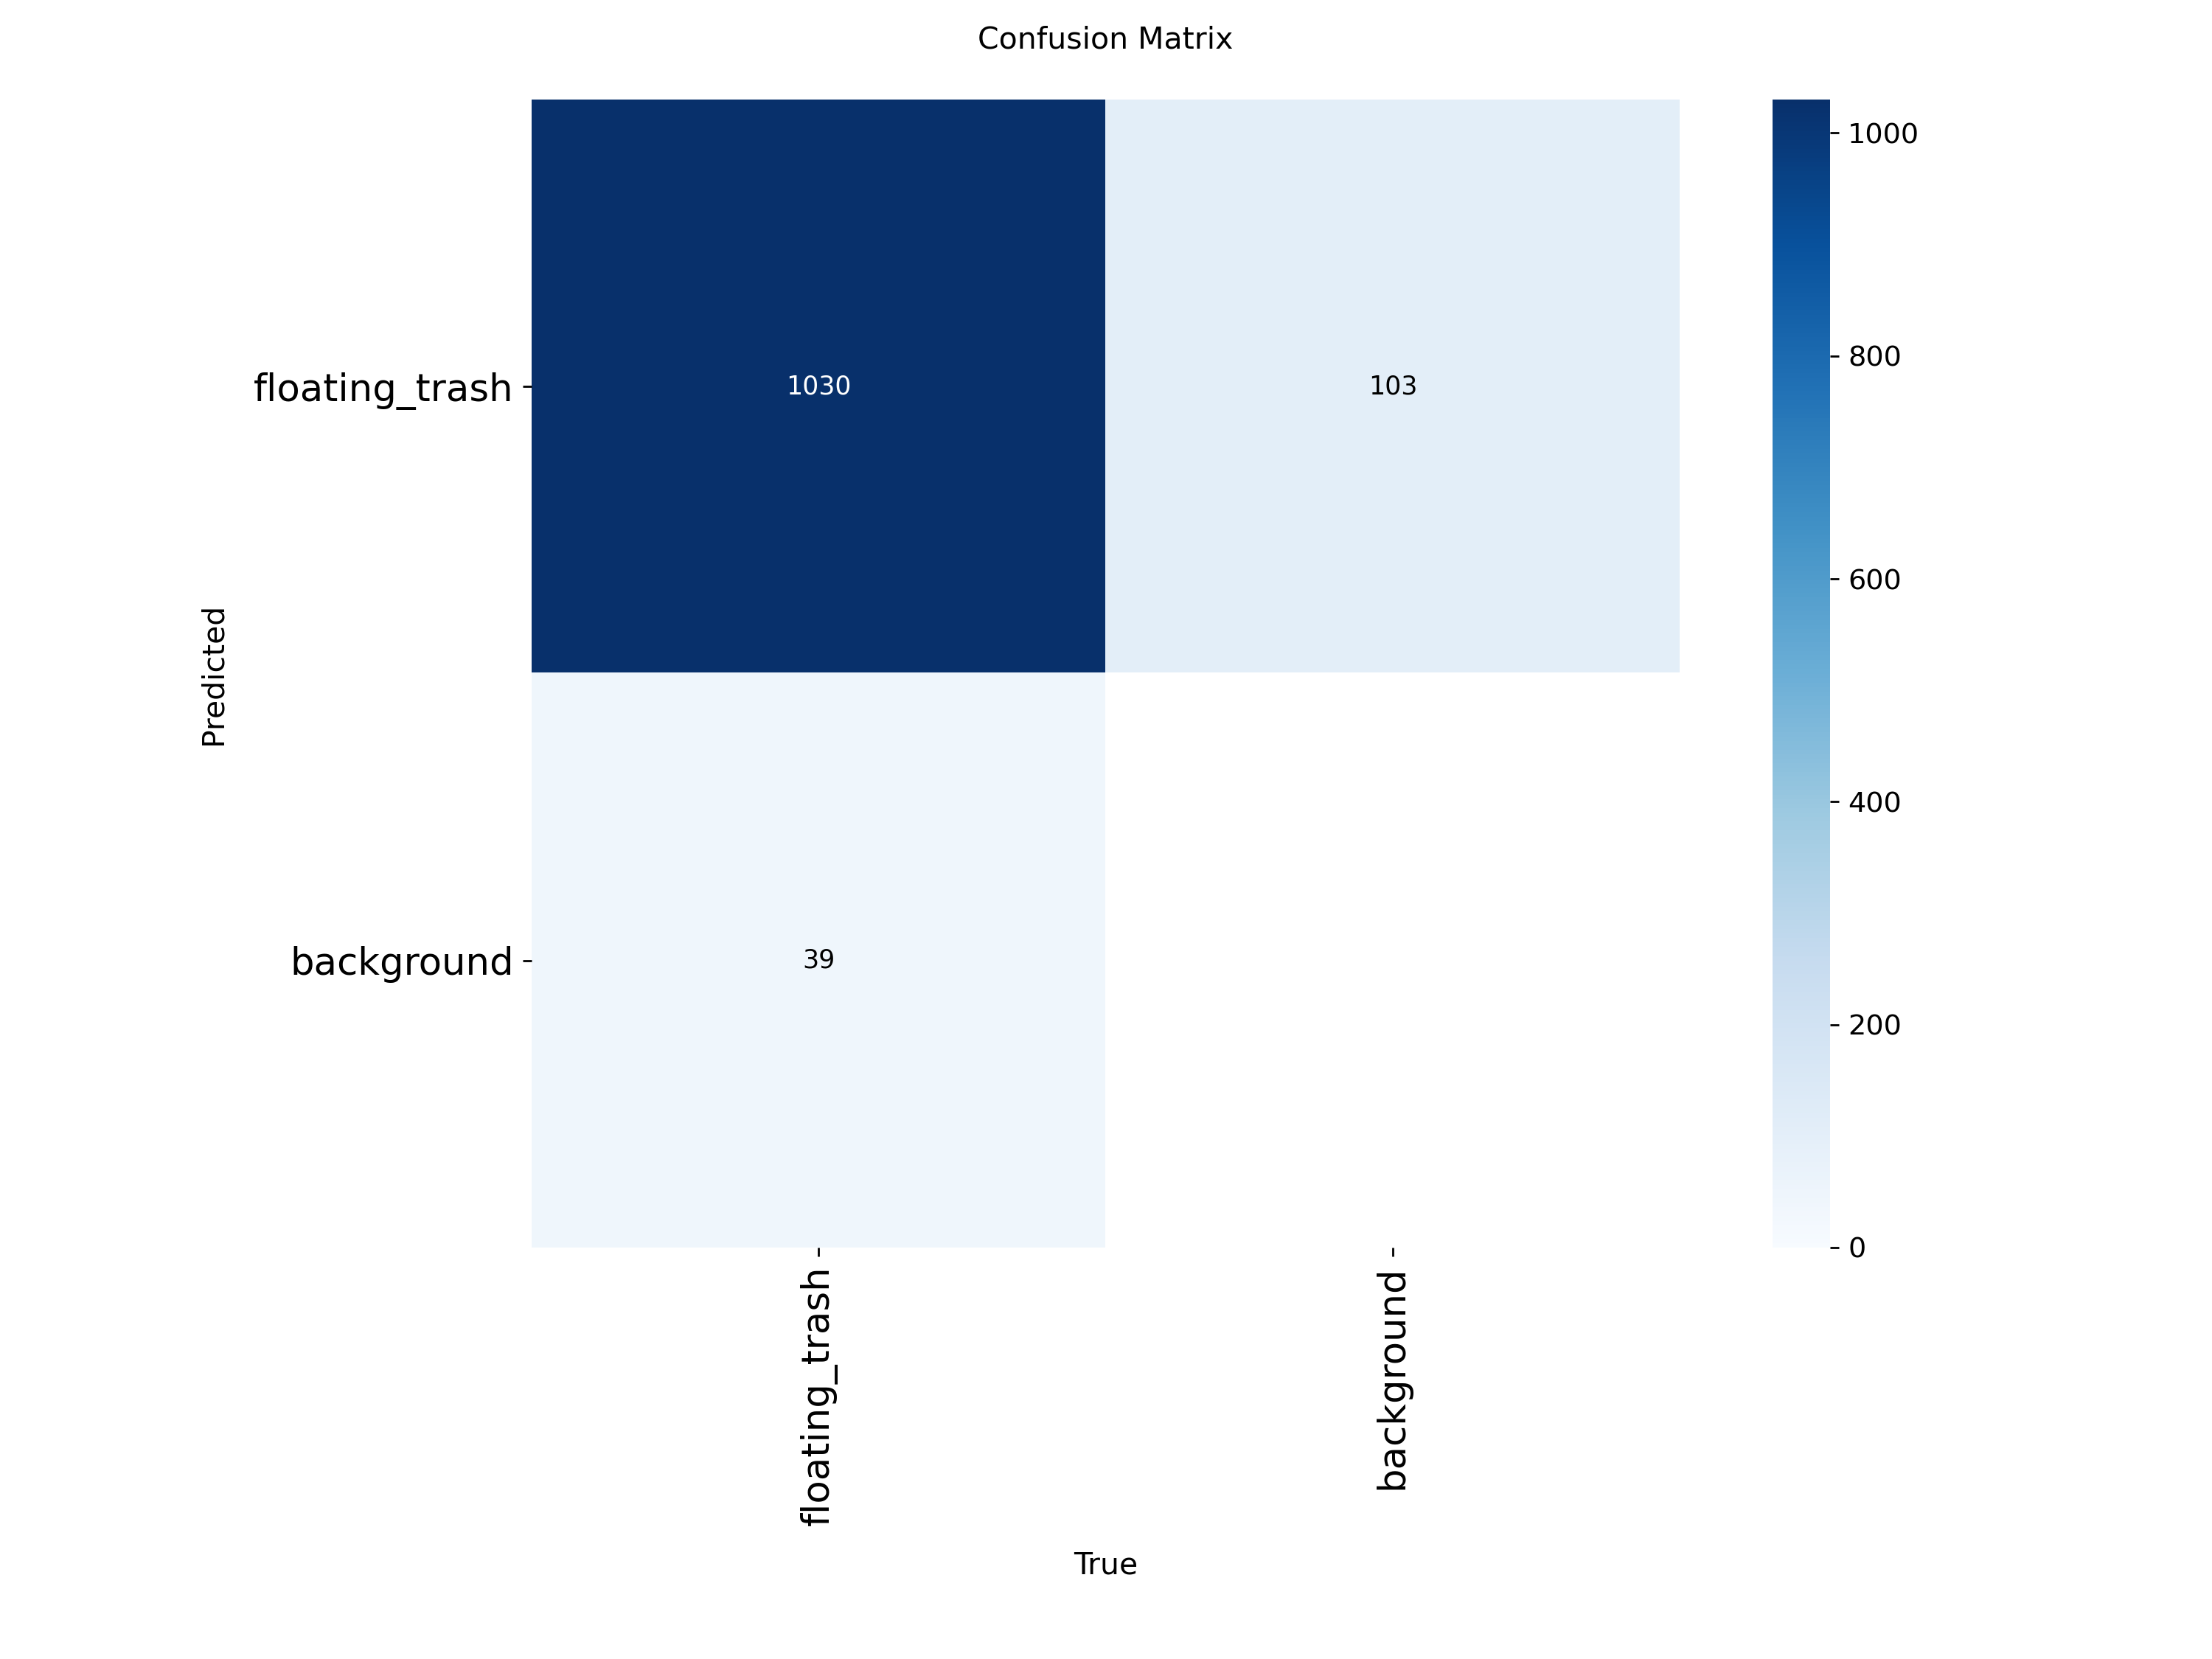

In [14]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

# 1. Configuration (Must match training block)
RUN_NAME = 'yolo11s_baseline_50e'
DATA_YAML = '/content/trash_dataset_yolo_comparison/dataset.yaml'

# 2. Locate the Best Weights
# First try local path, then fallback to Drive if local was cleared
local_weights = f'/content/runs/detect/{RUN_NAME}/weights/best.pt'
drive_weights = f'/content/drive/MyDrive/YOLO_Comparison_Study/checkpoints/{RUN_NAME}_best.pt'

if os.path.exists(local_weights):
    weights_path = local_weights
    print(f"Loading weights from local runtime: {weights_path}")
elif os.path.exists(drive_weights):
    weights_path = drive_weights
    print(f"Loading weights from Drive backup: {weights_path}")
else:
    raise FileNotFoundError("Could not find best.pt weights in local runs or Drive.")

# 3. Load Model & Validate
print("\n📊 Starting Evaluation on Validation Set...")
model = YOLO(weights_path)

# Run validation
# split='val' uses the validation set defined in your yaml
# split='test' can be used if you have a specific test folder defined in yaml
metrics = model.val(data=DATA_YAML, split='val', imgsz=640, project='/content/runs/detect', name=f'{RUN_NAME}_eval')

# 4. Print Key Metrics
print("\n" + "="*30)
print(f"🏆 EVALUATION RESULTS: {RUN_NAME}")
print("="*30)
print(f"mAP@50    (IoU=0.50):      {metrics.box.map50:.4f}")
print(f"mAP@50-95 (IoU=0.50:0.95): {metrics.box.map:.4f}")
print(f"Precision:                 {metrics.box.mp:.4f}")
print(f"Recall:                    {metrics.box.mr:.4f}")
print("="*30)

# 5. Display Confusion Matrix
# Ultralytics saves plots in the evaluation run folder
eval_dir = f'/content/runs/detect/{RUN_NAME}_eval'
conf_matrix_path = os.path.join(eval_dir, 'confusion_matrix.png')





if os.path.exists(conf_matrix_path):
    print("\n📉 Confusion Matrix:")
    display(Image(filename=conf_matrix_path, width=600))
else:
    print("\n⚠️ Confusion matrix image not found. Check the output directory.")

RTDETR MODEL

In [21]:
from ultralytics import RTDETR, settings
import os
import shutil
from google.colab import drive

# --- CONFIGURATION ---
RUN_NAME = 'rtdetr_transformer_50e'
# We use the same checkpoint dir as before to keep things organized
DRIVE_CHECKPOINT_DIR = '/content/drive/MyDrive/YOLO_Comparison_Study/checkpoints'

if not os.path.exists('/content/drive'): drive.mount('/content/drive')
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

# --- REUSING YOUR CALLBACK LOGIC ---
def save_to_drive_callback(trainer):
    """Copies weights to Drive at the end of every epoch."""
    local_last = trainer.last
    local_best = trainer.best
    drive_last = os.path.join(DRIVE_CHECKPOINT_DIR, f'{RUN_NAME}_last.pt')
    drive_best = os.path.join(DRIVE_CHECKPOINT_DIR, f'{RUN_NAME}_best.pt')

    if local_last and os.path.exists(local_last):
        shutil.copy(local_last, drive_last)
    if local_best and os.path.exists(local_best):
        shutil.copy(local_best, drive_best)

# --- TRAINING ---
print(f"\n🚀 Starting Training: {RUN_NAME} (Transformer)...")

# Load RT-DETR-l (Large is standard for this, but s/tiny versions exist if GPU is slow)
# We use 'rtdetr-l.pt' to give it the best chance against YOLO11
model = RTDETR('rtdetr-l.pt')

model.add_callback("on_train_epoch_end", save_to_drive_callback)

results = model.train(
    data='/content/trash_dataset_yolo_comparison/dataset.yaml',
    epochs=50,
    imgsz=640,
    batch=8, # Transformers take more VRAM, so we lower batch size slightly
    name=RUN_NAME,
    patience=10,
    augment=True,
    project='/content/runs/detect'
)
print("✅ RT-DETR Training Complete. Checkpoints in Drive.")


🚀 Starting Training: rtdetr_transformer_50e (Transformer)...
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/trash_dataset_yolo_comparison/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=rtdetr_transformer_50e, nbs=64, nms=False, opset=None,

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/50      8.23G      1.039      0.956     0.1704         14        640: 100% ━━━━━━━━━━━━ 223/223 1.5it/s 2:33
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.2it/s 12.9s
                   all        446       1069      0.784      0.794      0.748      0.222

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/50      8.52G     0.9003     0.4872     0.0964         34        640: 0% ──────────── 0/223  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/50      8.55G     0.8436     0.4338    0.09162         13        640: 100% ━━━━━━━━━━━━ 223/223 1.6it/s 2:19
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 3.1it/s 8.9s
                   all        446       1069      0.743      0.734      0.667       0.22

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/50      8.49G     0.8978     0.4551    0.08413         17        640: 0% ──────────── 0/223  0.7s

...

      48/50      8.59G     0.4351     0.3793    0.03813         12        640: 100% ━━━━━━━━━━━━ 223/223 1.6it/s 2:15
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 3.1it/s 9.0s
                   all        446       1069      0.945      0.949      0.942      0.536

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      49/50      8.63G     0.3852     0.3869    0.03509         27        640: 0% ──────────── 0/223  0.7s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      49/50      8.63G     0.4242     0.3718    0.03743         14        640: 100% ━━━━━━━━━━━━ 223/223 1.6it/s 2:18
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.6it/s 10.6s
                   all        446       1069      0.944      0.948      0.941      0.549

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      50/50      8.65G     0.3938     0.3799    0.03682         14        640: 0% ──────────── 0/223  0.7s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      50/50      8.69G      0.418     0.3748    0.03688         13        640: 100% ━━━━━━━━━━━━ 223/223 1.7it/s 2:15
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.8it/s 9.9s
                   all        446       1069      0.945       0.95      0.941      0.544

50 epochs completed in 2.342 hours.
Optimizer stripped from /content/runs/detect/rtdetr_transformer_50e/weights/last.pt, 66.2MB
Optimizer stripped from /content/runs/detect/rtdetr_transformer_50e/weights/best.pt, 66.2MB

Validating /content/runs/detect/rtdetr_transformer_50e/weights/best.pt...
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
rt-detr-l summary: 302 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.4it/s 11.7s
                   all        446       1069      0.944      0.948      0.941  

In [22]:
# @title Evaluate RT-DETR (Calculate mAP)
from ultralytics import RTDETR
import os
import pandas as pd
from google.colab import drive

# --- CONFIGURATION ---
RUN_NAME = 'rtdetr_transformer_50e'
DRIVE_CHECKPOINT_DIR = '/content/drive/MyDrive/YOLO_Comparison_Study/checkpoints'
DATA_YAML = '/content/trash_dataset_yolo_comparison/dataset.yaml'

if not os.path.exists('/content/drive'): drive.mount('/content/drive')

# --- 1. LOAD THE BEST MODEL ---
# We load the weights saved in Drive to ensure we test the absolute best version
weights_path = os.path.join(DRIVE_CHECKPOINT_DIR, f'{RUN_NAME}_best.pt')

if not os.path.exists(weights_path):
    print(f"⚠️ Warning: Best checkpoint not found at {weights_path}.")
    print("Trying to find the local run folder...")
    # Fallback to local run if Drive copy failed
    weights_path = f'/content/runs/detect/{RUN_NAME}/weights/best.pt'

if os.path.exists(weights_path):
    print(f"🔄 Loading Weights: {weights_path}")
    model = RTDETR(weights_path)
else:
    raise FileNotFoundError("❌ Could not find trained weights. Did training finish?")

# --- 2. RUN VALIDATION ---
print("\n🚀 Starting Evaluation Loop (RT-DETR)...")
# arguments: splits='val' ensures we test on validation set
metrics = model.val(data=DATA_YAML, split='val', plots=True)

# --- 3. EXTRACT & PRINT METRICS ---
# Ultralytics stores results in the .box attribute
map50 = metrics.box.map50
map50_95 = metrics.box.map
precision = metrics.box.mp
recall = metrics.box.mr

print("\n" + "="*50)
print(f"📊 EVALUATION RESULTS: {RUN_NAME}")
print("="*50)
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"mAP @ 50:      {map50:.4f}  <-- Comparable to Base Paper")
print(f"mAP @ 50-95:   {map50_95:.4f}  <-- COCO Standard")
print("="*50)

# --- 4. SAVE FOR FINAL COMPARISON ---
# We save this small CSV to make the final "Comparison Block" easier to run
results_dir = f'/content/runs/detect/{RUN_NAME}'
os.makedirs(results_dir, exist_ok=True)

df_res = pd.DataFrame([{
    'Model': 'RT-DETR-l',
    'mAP@50': map50,
    'mAP@50-95': map50_95,
    'Precision': precision,
    'Recall': recall
}])
df_res.to_csv(f'{results_dir}/final_metrics.csv', index=False)
print(f"✅ Metrics saved to {results_dir}/final_metrics.csv")

🔄 Loading Weights: /content/drive/MyDrive/YOLO_Comparison_Study/checkpoints/rtdetr_transformer_50e_best.pt

🚀 Starting Evaluation Loop (RT-DETR)...
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
rt-detr-l summary: 305 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3207.6±570.1 MB/s, size: 226.0 KB)
val: Scanning /content/trash_dataset_yolo_comparison/labels/val.cache... 446 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 446/446 810.2Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 1.4it/s 20.5s
                   all        446       1069      0.944      0.949       0.94      0.549
Speed: 2.7ms preprocess, 39.0ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /content/runs/detect/val

📊 EVALUATION RESULTS: rtdetr_transformer_50e
Precision:     0.9442
Recall:        0.9492
mAP @ 50:      0.94